In [52]:
import pandas as pd
import  numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt 
import seaborn as sns 
import datetime as dt
from datetime import datetime
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.decomposition import PCA

In [53]:
df= pd.read_csv("data.csv")
display(df)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,"2,55",17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,"3,39",17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,"2,75",17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,"3,39",17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,"3,39",17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/11 12:50,"0,85",12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/11 12:50,"2,1",12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/11 12:50,"4,15",12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/11 12:50,"4,15",12680.0,France


## EDA

In [54]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  str    
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(1), int64(1), str(6)
memory usage: 68.3 MB


In [55]:
df.shape

(541909, 8)

In [56]:
df.head()
df.columns


Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [57]:

df.dtypes


InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice          str
CustomerID     float64
Country            str
dtype: object

In [58]:
df.describe()

,Quantity,CustomerID
count,541909.000000,406829.000000
mean,9.552250,15287.690570
std,218.081158,1713.600303
min,-80995.000000,12346.000000
25%,1.000000,13953.000000
50%,3.000000,15152.000000
75%,10.000000,16791.000000
max,80995.000000,18287.000000


### data preparing

In [59]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

### convert InvocieNo to float

### traiter  les donness manquantes

In [60]:
df.dropna(subset=['CustomerID'],inplace=True)
df.isna().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

### Analyse CostumerID 

In [61]:
df['CustomerID'].head()
df['CustomerID'].dtype

df['CustomerID'].isna().sum()

df['CustomerID'].nunique()


4372

In [62]:
df['CustomerID'].value_counts().describe()     

count    4372.000000
mean       93.053294
std       232.471608
min         1.000000
25%        17.000000
50%        42.000000
75%       102.000000
max      7983.000000
Name: count, dtype: float64

In [63]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])
df.dtypes

C:\Users\Youcode\AppData\Local\Temp\ipykernel_13904\2208571527.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])


InvoiceNo                 str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice                 str
CustomerID            float64
Country                   str
dtype: object

## traiter les donnees  

In [64]:
df_uniq=df['CustomerID'].isna().sum()
print(df_uniq)
df
df['UnitPrice']=df['UnitPrice'].str.replace(',','.').astype(float)

0


<Axes: xlabel='Country'>

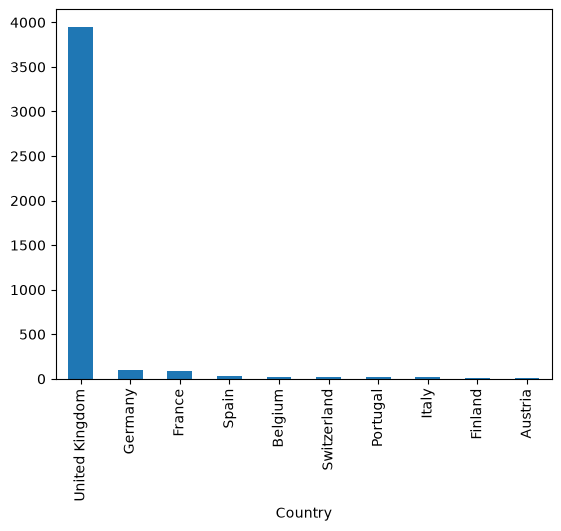

In [65]:
filtered_data=df[['Country','CustomerID']].drop_duplicates()


filtered_data.Country.value_counts()[:10].plot(kind='bar')

### RFM

In [66]:
df_rfm = df.copy()
df_rfm = df_rfm[df_rfm['Quantity'] > 0]
df_rfm = df_rfm[df_rfm['UnitPrice'] > 0]

print(df_rfm.shape)
df_rfm.head()

(397884, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


### Frequency

In [67]:
freq = df_rfm.groupby('CustomerID')['InvoiceNo'].nunique().rename('Frequence')
freq.head()

CustomerID
12346.0    1
12347.0    7
12348.0    4
12349.0    1
12350.0    1
Name: Frequence, dtype: int64

### Recency

In [68]:

Now = df_rfm['InvoiceDate'].max() + pd.Timedelta(days=1)

last_sales = df_rfm.groupby('CustomerID')['InvoiceDate'].max()

recence = (Now - last_sales).dt.days.rename('Recence')
recence.head()

CustomerID
12346.0    326
12347.0      2
12348.0     75
12349.0     19
12350.0    310
Name: Recence, dtype: int64

### Monetary

In [69]:
df_rfm['Total_Price'] = df_rfm['Quantity'] * df_rfm['UnitPrice']

montant = df_rfm.groupby('CustomerID')['Total_Price'].sum().rename('Montant')
montant.head()

CustomerID
12346.0    77183.60
12347.0     4310.00
12348.0     1797.24
12349.0     1757.55
12350.0      334.40
Name: Montant, dtype: float64

In [70]:
rfm = pd.concat([recence, freq, montant], axis=1).reset_index()
rfm.columns = ['CustomerID', 'Recence', 'Frequence', 'Montant']

print(rfm.shape)
print(rfm.isna().sum())
rfm.head()

(4338, 4)
CustomerID    0
Recence       0
Frequence     0
Montant       0
dtype: int64


,CustomerID,Recence,Frequence,Montant
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


### des indicateurs RFM
Recence:Nombre de jours depuis le dernier achat du client

frequence : Nombre de commandes distinctes passees par le client

Montery : Somme totale depensee par le client

#### Préparation des variables pour le clustering

In [71]:

rfm[['Recence', 'Frequence', 'Montant']].describe()

,Recence,Frequence,Montant
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


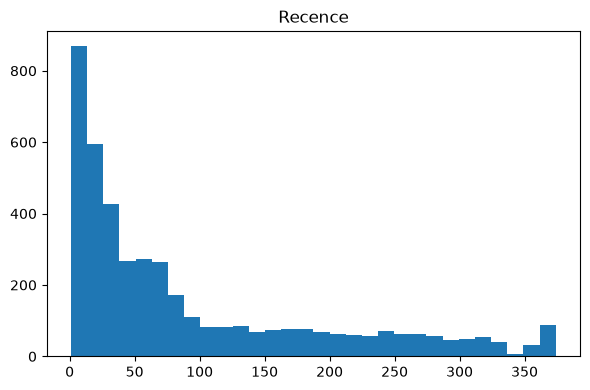

In [72]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(rfm['Recence'], bins=30)
ax.set_title('Recence')
plt.tight_layout()
plt.show()

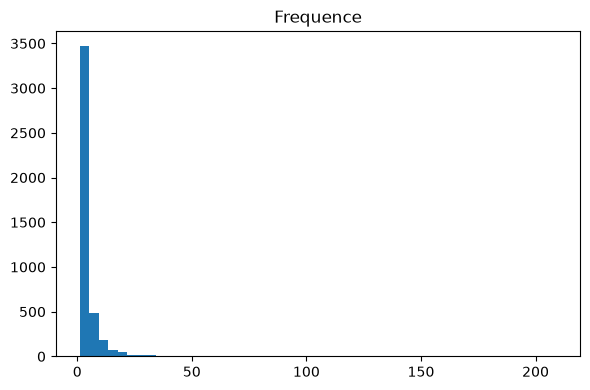

In [73]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(rfm['Frequence'], bins=50)
ax.set_title('Frequence')
plt.tight_layout()
plt.show()

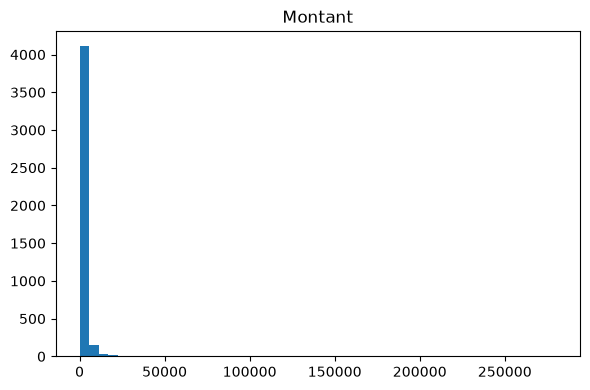

In [74]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(rfm['Montant'], bins=50)
ax.set_title('Montant')
plt.tight_layout()
plt.show()

In [75]:
rfm['Recence'] = np.log1p(rfm['Recence'])
rfm['Frequence'] = np.log1p(rfm['Frequence'])
rfm['Montant'] = np.log1p(rfm['Montant'])

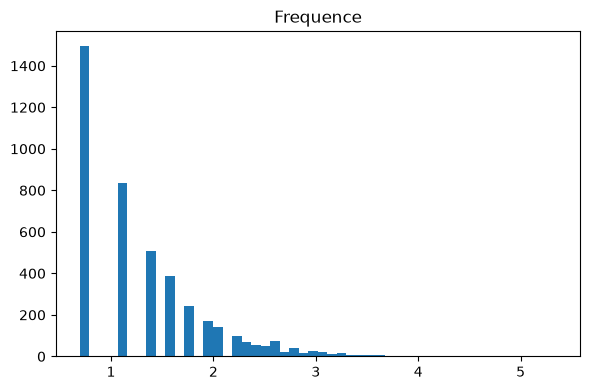

In [76]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(rfm['Frequence'], bins=50)
ax.set_title('Frequence')
plt.tight_layout()
plt.show()

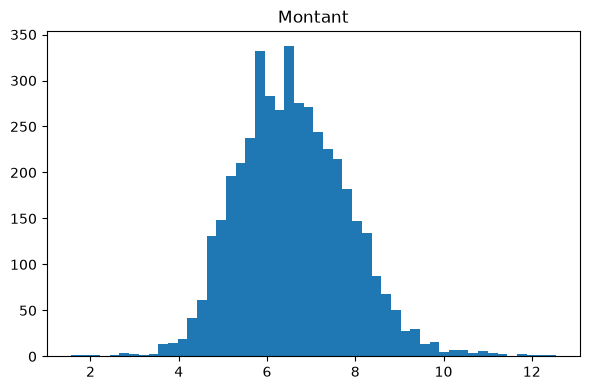

In [77]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(rfm['Montant'], bins=50)
ax.set_title('Montant')
plt.tight_layout()
plt.show()

### Standarisation

In [78]:
features = ['Recence', 'Frequence', 'Montant']
X = rfm[features]
scaler = StandardScaler()
rfmScaled=scaler.fit_transform(X)
display(rfmScaled)
type(rfmScaled)

array([[ 1.46199281, -0.95521426,  3.70622476],
       [-2.03873442,  1.07442519,  1.41184341],
       [ 0.37310424,  0.38630445,  0.7164889 ],
       ...,
       [-1.21893976, -0.36158278, -1.11812113],
       [-1.65755161,  2.17800394,  0.83829669],
       [-0.03473174,  0.05960547,  0.73400231]], shape=(4338, 3))

numpy.ndarray

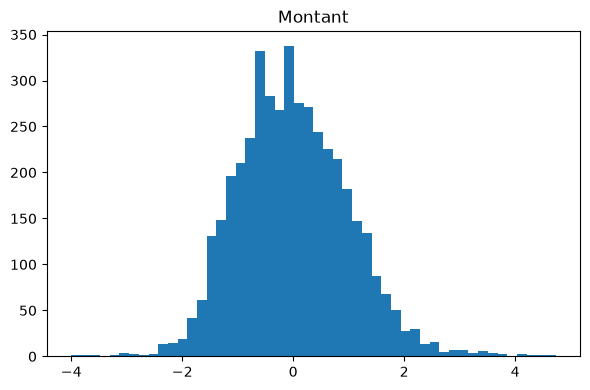

In [79]:
features = ['Recence', 'Frequence', 'Montant']
rfm_scaled = pd.DataFrame(rfmScaled, columns=features, index=rfm['CustomerID'])
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(rfm_scaled['Montant'], bins=50)
ax.set_title('Montant')
plt.tight_layout()
plt.show()

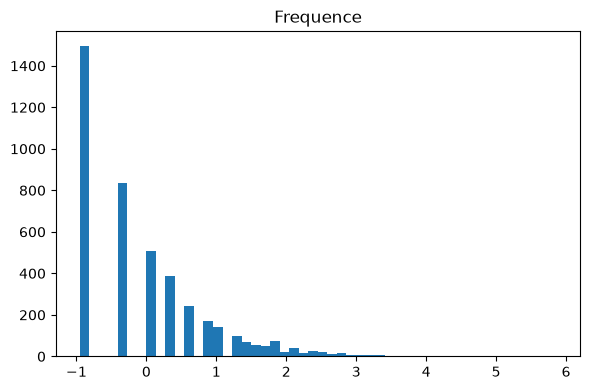

In [80]:

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(rfm_scaled['Frequence'], bins=50)
ax.set_title('Frequence')
plt.tight_layout()
plt.show()

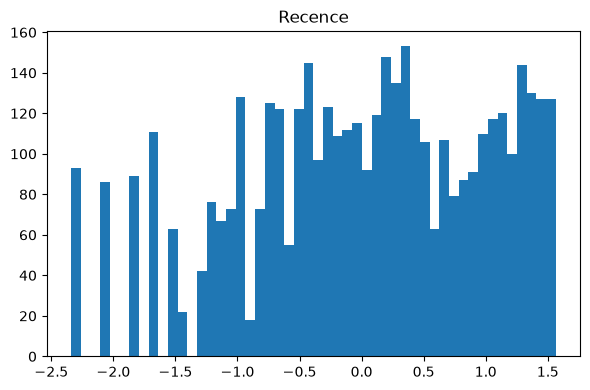

In [81]:

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(rfm_scaled['Recence'], bins=50)
ax.set_title('Recence')
plt.tight_layout()
plt.show()

### Segmentation avec K-Means

In [82]:
inertias = []


for k in range(1, 20):
    kmeans = KMeans(n_clusters=k,random_state=42,n_init=10)
    
    kmeans.fit(rfmScaled)
    inertias.append(kmeans.inertia_)
    predicted_labels = kmeans.fit_predict(rfmScaled)
 

In [83]:
print(inertias)

[13014.000000000004, 6481.225323423515, 4867.846645267559, 3938.5099536013217, 3295.97632879243, 2855.01124700141, 2548.9143244239403, 2336.7775084644077, 2155.6481927332134, 1999.903269751348, 1872.8327992347972, 1765.27167390351, 1673.3992653928954, 1590.2596801948748, 1513.3979078297334, 1455.8424362999713, 1396.769129019068, 1348.7010949977691, 1300.1470585199993]


## Elbow Method

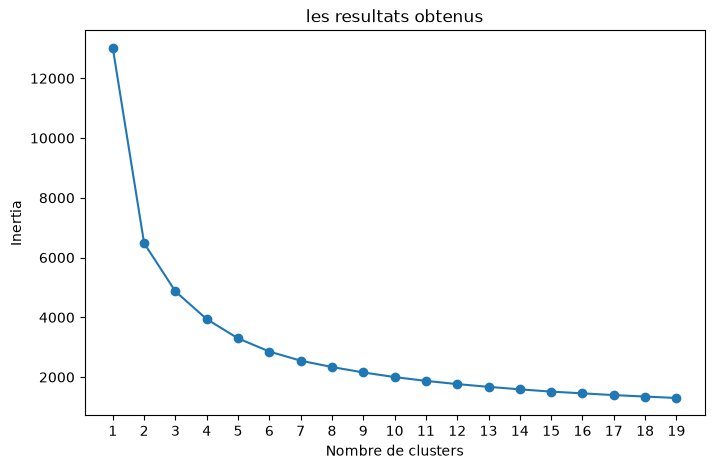

In [84]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 20), inertias, marker='o')
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertia")
plt.title("les resultats obtenus")
plt.xticks(range(1, 20))
plt.show()

In [85]:
Estimation =range(2,8)

###  coefficient de Silhouette 

In [86]:
silhouette_scores = []

for k in Estimation:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    predicted_labels = km.fit_predict(rfmScaled)
    silhouette_val = silhouette_score(rfmScaled, predicted_labels)
    silhouette_scores.append(silhouette_val)
    print(f"pour ce k:{k} silhouette_score:{silhouette_val}")
print(km.labels_)


pour ce k:2 silhouette_score:0.43294018131896606
pour ce k:3 silhouette_score:0.33650963406696927
pour ce k:4 silhouette_score:0.3371343622222519
pour ce k:5 silhouette_score:0.31609724178691406
pour ce k:6 silhouette_score:0.31332900440932415
pour ce k:7 silhouette_score:0.3099750749146704
[6 1 6 ... 4 1 6]


C:\Users\Youcode\AppData\Local\Temp\ipykernel_13904\1683976043.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


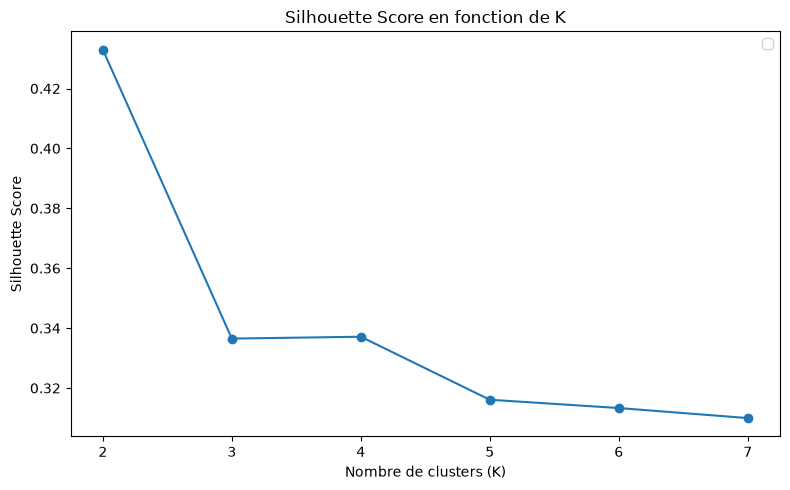

In [87]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(Estimation), silhouette_scores, marker='o')
ax.set_xlabel('Nombre de clusters (K)')
ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette Score en fonction de K')

ax.legend()
plt.tight_layout()
plt.show()

### Le K ayant le meilleur coefficient de silhouette (0.43) est K=2

In [88]:
k=2
km = KMeans(n_clusters=2,random_state=42,n_init=10)

km.fit(rfmScaled)

predicted_labels = km.fit_predict(rfmScaled)
silhouette_val=silhouette_score(rfmScaled,predicted_labels)
print(f"pour ce 2: silhouette_score:{silhouette_val}")
    
print(km.labels_)

pour ce 2: silhouette_score:0.43294018131896606
[1 1 1 ... 0 1 1]


### la contrainte metier : k=3

### K=2 vs K=3
Le Silhouette Score indique que K=2 donne la meilleure separation statistique entre
les clients. Mais l'entreprise a besoin de 3 segments pour adapter ses actions
marketing (clients fidles, intermédiaires, inactifs)
On garde donc K=3, un
compromis entre ce que dit l'algorithme et ce dont le métier a besoin

K=3 est retenu non pas pour des raisons statistiques (le Silhouette Score préfère K=2)
mais parce que le metier a besoin de 3 segments distincts pour cibler ses actions marketing

## K means avec K-3

In [89]:
Km=KMeans(n_clusters=3,random_state=42)
Km.fit(rfmScaled)
Km.labels_

array([0, 1, 0, ..., 0, 1, 0], shape=(4338,), dtype=int32)

## Ajouter Clusters au tableau

In [90]:
rfm_scaled["Cluster"]= Km.labels_
print(rfm_scaled)
print(f"on a {rfm_scaled['Cluster'].unique().sum() } clusters")
print(rfm_scaled)

             Recence  Frequence   Montant  Cluster
CustomerID                                        
12346.0     1.461993  -0.955214  3.706225        0
12347.0    -2.038734   1.074425  1.411843        1
12348.0     0.373104   0.386304  0.716489        0
12349.0    -0.623086  -0.955214  0.698739        0
12350.0     1.424558  -0.955214 -0.618962        2
...              ...        ...       ...      ...
18280.0     1.343533  -0.955214 -1.106875        2
18281.0     1.024749  -0.955214 -1.740933        2
18282.0    -1.218940  -0.361583 -1.118121        0
18283.0    -1.657552   2.178004  0.838297        1
18287.0    -0.034732   0.059605  0.734002        0

[4338 rows x 4 columns]
on a 3 clusters
             Recence  Frequence   Montant  Cluster
CustomerID                                        
12346.0     1.461993  -0.955214  3.706225        0
12347.0    -2.038734   1.074425  1.411843        1
12348.0     0.373104   0.386304  0.716489        0
12349.0    -0.623086  -0.955214  0.698739

### analyser les caracteistiques des 3 clusters

In [91]:
RFM=np.expm1(
    scaler.inverse_transform(rfm_scaled[['Recence', 'Frequence', 'Montant']]))

RFM= pd.DataFrame(RFM,
                  columns=['Recence', 'Frequence', 'Montant'],
                  index=rfm_scaled.index
                  )
RFM['Cluster']=rfm_scaled['Cluster']
profil_clusters=RFM.groupby('Cluster').agg(
    Nombre_Clients=('Recence', 'count'),
    Recence_Moyenne=('Recence','mean'),
    Frequence_moyenne=('Frequence', 'mean'),
    Montant_moyen=('Montant', 'mean'),
    Montant_total=('Montant', 'sum')
)

print(profil_clusters)

         Nombre_Clients  Recence_Moyenne  Frequence_moyenne  Montant_moyen  \
Cluster                                                                      
0                  1696        44.463443           3.368514    1257.688940   
1                   776        17.070876          13.274485    7865.636662   
2                  1866       167.613076           1.349411     361.539877   

         Montant_total  
Cluster                 
0          2133040.443  
1          6103734.050  
2           674633.411  


### Visualisation des segments avec PCA

In [92]:
features = ['Recence', 'Frequence', 'Montant']

pca = PCA(n_components=2)
principalCom = pca.fit_transform(rfm_scaled[features])

prin_DF = pd.DataFrame(data=principalCom, columns=['Pca1', 'pca2'])


In [93]:
prin_DF['Cluster'] = rfm_scaled['Cluster'].values
prin_DF.head()

,Pca1,pca2,Cluster
0,0.872658,2.686758,0
1,2.550260,-0.804427,1
2,0.475142,0.746121,0
3,0.145832,-0.460480,0
4,-1.688990,0.676555,2


### scattter plot pour pca

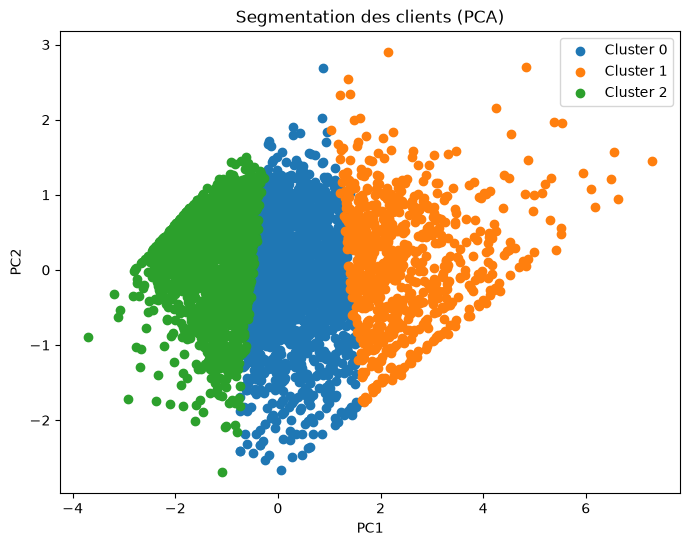

In [94]:
fig, ax = plt.subplots(figsize=(8, 6))

for cluster in range(3):
    subset = prin_DF[prin_DF['Cluster'] == cluster]
    ax.scatter(subset['Pca1'], subset['pca2'], label=f'Cluster {cluster}')

ax.set(xlabel='PC1', ylabel='PC2', title='Segmentation des clients (PCA)')
ax.legend()
plt.show()

pca reduire les donnes en 2 dimensions,, et ausii

### trouver les Centroids

In [106]:
centroids_original=np.expm1(scaler.inverse_transform(Km.cluster_centers_))

centroids_df= pd.DataFrame(centroids_original,
                           columns=['Recence', 'Frequence', 'Montant'])

print(centroids_df)


      Recence  Frequence      Montant
0   28.729910   3.091777   952.899969
1    9.216028  10.611609  4240.636865
2  128.104287   1.281118   273.314944


### DBSCAN